In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f1 only
function_folder = os.path.join(base_dir, "function_1")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f1 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 1: shape = {df_f1.shape}, columns = {df_f1.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']


In [3]:
week1_results = {"f1": ([0.793600, 0.666269], 1.4034986520274933e-21),}

In [4]:
week2_results = {"f1": ([0.800601, 0.002800], 9.069108791316283e-223)}

In [5]:
week3_results = {"f1": ([0.729726, 0.729276], 5.31459276351908e-15),}

In [6]:
week4_results = {"f1": ([0.732162, 0.364472], 5.473776123300507e-57),}

In [7]:
week5_results = {"f1": ([0.812650, 0.143347], -1.0629331180647184e-161),}

In [8]:
week6_results = {"f1": ([0.079265, 0.909848], 2.6078826238924974e-248),}

In [9]:
week7_results = {"f1": ([0.525569, 0.987823], 2.2360328065267756e-98),}

In [10]:
week8_results = {"f1": ([0.994902, 0.994221], 3.029971271826444e-187),}

In [11]:
week9_results = {"f1": ([0.684583, 0.725353], 1.8670441080687443e-9),}

In [12]:
week10_results = {"f1": ([0.684583, 0.718000], 2.03320460262336e-8),}

In [13]:
week11_results = {"f1": ([0.684583, 0.705339], 6.49621320377074e-7),}

In [14]:
week12_results = {"f1": ([0.684583, 0.694641], 0.000006604888098994687),}

In [15]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f1

for week, results in weekly_results.items():
    
    if "f1" not in results:
        continue
    
    inputs, output = results["f1"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f1
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "y1"]
    )
    
    # append to df_f1
    df_f1 = pd.concat([df_f1, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f1 = df_f1.drop_duplicates(ignore_index=True)

print("updated f1 shape:", df_f1.shape)


updated f1 shape: (22, 3)


In [16]:
print(df_f1)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
17  0.994902  0.994221  3.029971e-187
18  0.684583  0.725353   1.867044e-09
19  0.684583  0.718000   2.033205e-08
20  0.684583  0.705339   6.496213e-07
21  0.684583  0.694641   6.604888e-06


In [17]:
display(df_f1.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,22.0,0.622499,0.242805,0.079265,5.377591e-01,6.845830e-01,7.782405e-01,0.994902
X2,22.0,0.592572,0.302152,0.002800,3.742259e-01,6.999900e-01,7.554695e-01,0.994221
y1,22.0,-0.000164,0.000769,-0.003606,7.574928e-188,2.736888e-57,5.783160e-16,0.000007


## Pearson Correlation

f1 Pearson Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,0.019596,-0.025285
X2,0.019596,1.000000,-0.065596
y1,-0.025285,-0.065596,1.000000


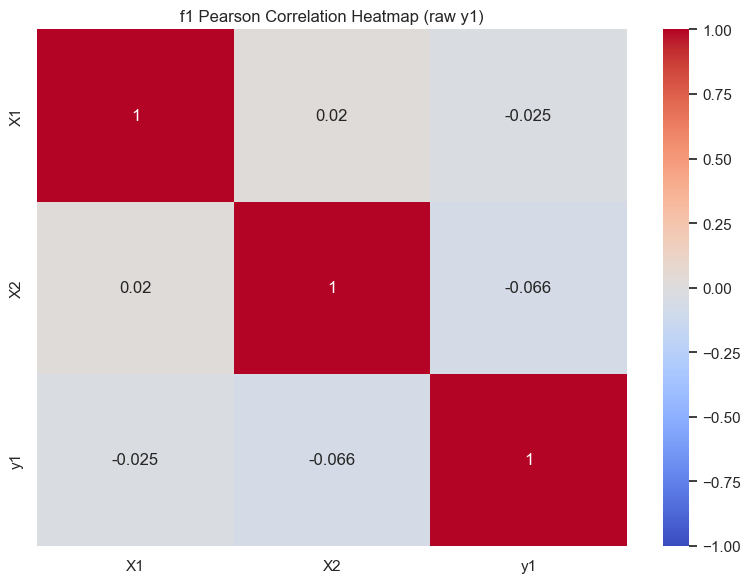

In [18]:
df_raw = df_f1.copy()

print("f1 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

f1 Pearson Correlation Matrix (copula-transformed y1)


,X1,X2,y1
X1,1.000000,0.019596,0.261274
X2,0.019596,1.000000,0.424056
y1,0.261274,0.424056,1.000000


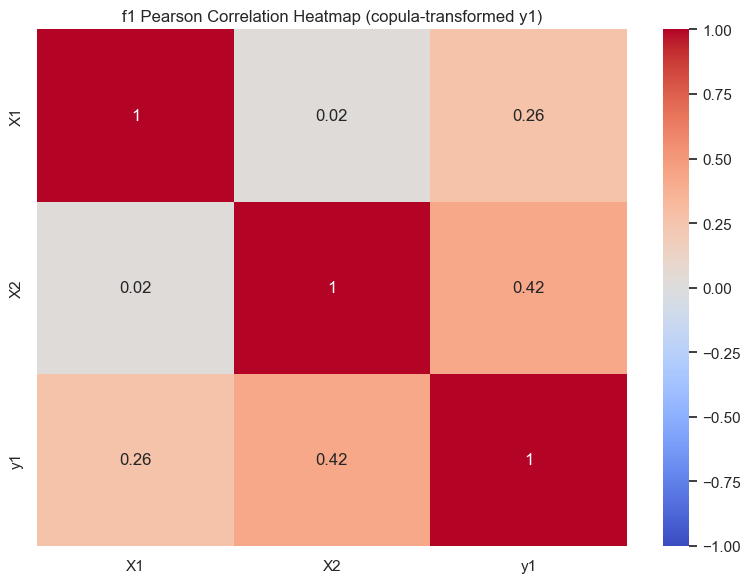

In [19]:
from scipy.stats import norm

df_copula = df_f1.copy()

y = df_copula["y1"].values

def gaussian_copula_transform(y):
    n = len(y)
    ranks = np.argsort(np.argsort(y)) + 1
    quantiles = ranks / (n + 1)
    return norm.ppf(quantiles)
    
y_copula = gaussian_copula_transform(y)

df_copula["y1"] = y_copula

print("f1 Pearson Correlation Matrix (copula-transformed y1)")

corr_copula = df_copula.corr()
display(corr_copula)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_copula,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Pearson Correlation Heatmap (copula-transformed y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f1 Spearman Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,-0.203285,0.179502
X2,-0.203285,1.000000,0.328063
y1,0.179502,0.328063,1.000000


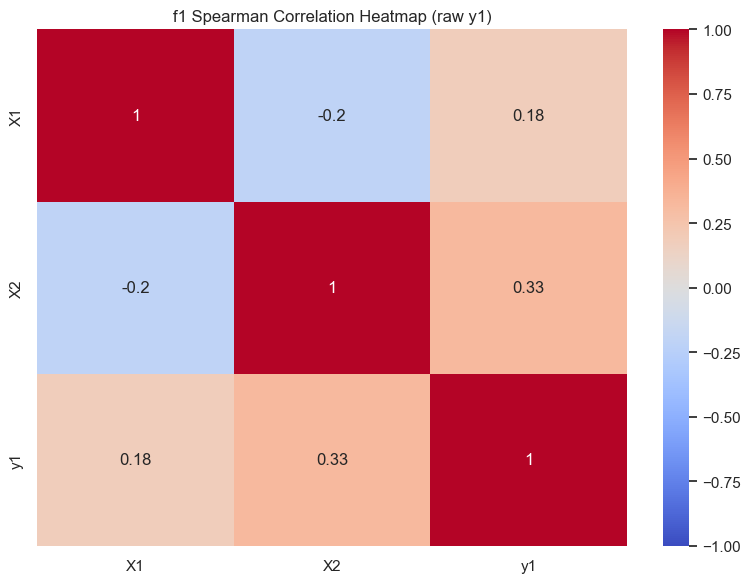

In [20]:
# spearman correlation with raw y1
df_raw = df_f1.copy()

print("f1 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f1 Kendall Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,-0.171067,0.083341
X2,-0.171067,1.000000,0.160173
y1,0.083341,0.160173,1.000000


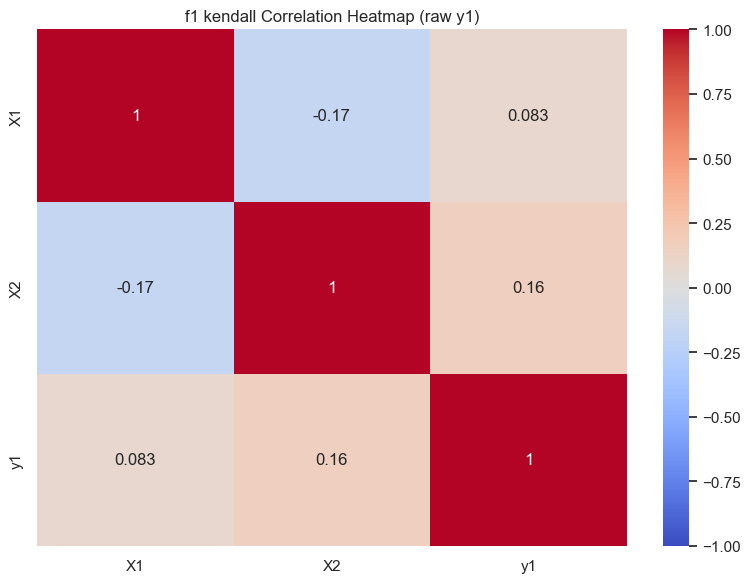

In [21]:
# Kendall correlation with raw y1
df_raw = df_f1.copy()

print("f1 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information 

In [22]:
from sklearn.feature_selection import mutual_info_regression

In [23]:
print("f1 (Copula-Transformed y1) — Mutual Information with Output")

# copy f1
df_f1_copula = df_f1.copy()

# apply copula transform
y = df_f1_copula["y1"].values
y_copula = gaussian_copula_transform(y)

df_f1_copula["y1"] = y_copula

# define inputs and output
input_cols_f1 = [c for c in df_f1_copula.columns if c.startswith("X")]
output_col_f1 = "y1"

X_f1 = df_f1_copula[input_cols_f1].values
y_f1 = df_f1_copula[output_col_f1].values

# compute mutual information
mi_f1_copula = mutual_info_regression(X_f1, y_f1, random_state=42)

# build dataframe
mi_f1_copula_df = pd.DataFrame({
    "Feature": input_cols_f1,
    "Mutual_Info": mi_f1_copula
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f1_copula_df)


f1 (Copula-Transformed y1) — Mutual Information with Output


,Feature,Mutual_Info
1,X2,0.438129
0,X1,0.134404


## Partial Correlation

In [24]:
!pip install pingouin
import pingouin as pg

In [25]:
print("f1 (Raw y1) — Partial Correlation")

# copy raw f1
df_f1_raw = df_f1.copy()

# define inputs and output
input_cols_f1 = [c for c in df_f1_raw.columns if c.startswith("X")]
output_col_f1 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f1:
    covars = [c for c in input_cols_f1 if c != x]  # all other X's as covariates
    
    pcorr_raw_f1 = pg.partial_corr(
        data=df_f1_raw,
        x=x,
        y=output_col_f1,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f1)



f1 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,22,-0.024056,"[-0.45, 0.41]",0.917564



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,22,-0.065133,"[-0.48, 0.38]",0.779094


In [26]:
print("f1 (Copula-Transformed y1) — Partial Correlation")

# copy f1
df_f1_copula = df_f1.copy()

# apply copula transform
y = df_f1_copula["y1"].values
y_copula = gaussian_copula_transform(y)

df_f1_copula["y1"] = y_copula

# define inputs and output
input_cols_f1 = [c for c in df_f1_copula.columns if c.startswith("X")]
output_col_f1 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f1:
    covars = [c for c in input_cols_f1 if c != x]
    
    pcorr_copula_f1 = pg.partial_corr(
        data=df_f1_copula,
        x=x,
        y=output_col_f1,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_copula_f1)


f1 (Copula-Transformed y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,22,0.279376,"[-0.17, 0.63]",0.220022



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,22,0.434095,"[0.0, 0.73]",0.049276


## Jackknife Correlation Stability


In [27]:
from scipy.stats import spearmanr

In [28]:
def jackknife_correlation_stability(x, y):
    """
    compute jackknife stability of the spearman correlation
    between a feature x and target y.

    the idea:
      remove one observation at a time
      recompute spearman correlation
      collect all jackknife correlations
      compute the standard deviation across them

    interpretation:
      std < 0.10  means stable signal
      std > 0.10  means unstable signal
    """

    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    # store jackknife correlations
    jackknife_rhos = []

    for i in range(n):
        # remove the i-th observation
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        x_jk = x[mask]
        y_jk = y[mask]

        # compute spearman correlation on the reduced dataset
        rho, _ = spearmanr(x_jk, y_jk)
        jackknife_rhos.append(rho)

    jackknife_rhos = np.array(jackknife_rhos)
    rho_mean = jackknife_rhos.mean()
    rho_std = jackknife_rhos.std()

    print("jackknife correlation stability")
    print(f"original spearman rho: {spearmanr(x, y)[0]:.4f}")
    print(f"jackknife mean rho:    {rho_mean:.4f}")
    print(f"jackknife std rho:     {rho_std:.4f}")

    if rho_std > 0.10:
        print("signal is unstable (std > 0.10)")
    else:
        print("signal is stable (std <= 0.10)")

    return jackknife_rhos, rho_mean, rho_std

In [29]:
print("Jackknife Spearman Stability (raw y1)")

df_raw = df_f1.copy()
input_cols = [c for c in df_raw.columns if c.startswith("X")]
y = df_raw["y1"].values

for xcol in input_cols:
    print(f"Feature: {xcol}")
    x = df_raw[xcol].values
    jackknife_correlation_stability(x, y)

Jackknife Spearman Stability (raw y1)
Feature: X1
jackknife correlation stability
original spearman rho: 0.1795
jackknife mean rho:    0.1789
jackknife std rho:     0.0494
signal is stable (std <= 0.10)
Feature: X2
jackknife correlation stability
original spearman rho: 0.3281
jackknife mean rho:    0.3269
jackknife std rho:     0.0473
signal is stable (std <= 0.10)


## Pairwise scatter coloured by y rank


Feature vs y1 (Gaussian Copula) for f1


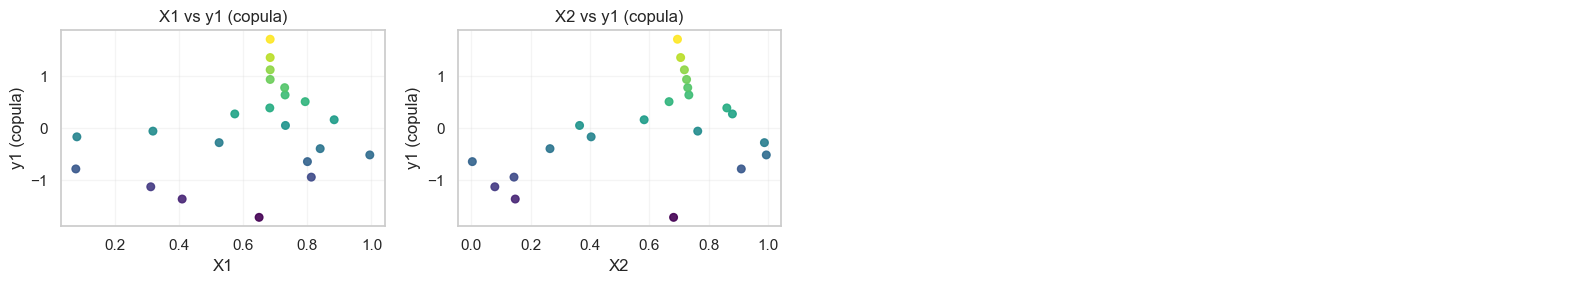

In [30]:
# === Feature vs copula-transformed y1 for f1 ===
print("\nFeature vs y1 (Gaussian Copula) for f1")

# number of input features
n_features = X_f1.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f1):
    ax = axes[j]
    sc = ax.scatter(
        X_f1[:, j],
        y_f1,
        c=y_f1,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (copula)")
    ax.set_title(f"{col} vs y1 (copula)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Log10(y) vs X2 in the Peak Neighbourhood

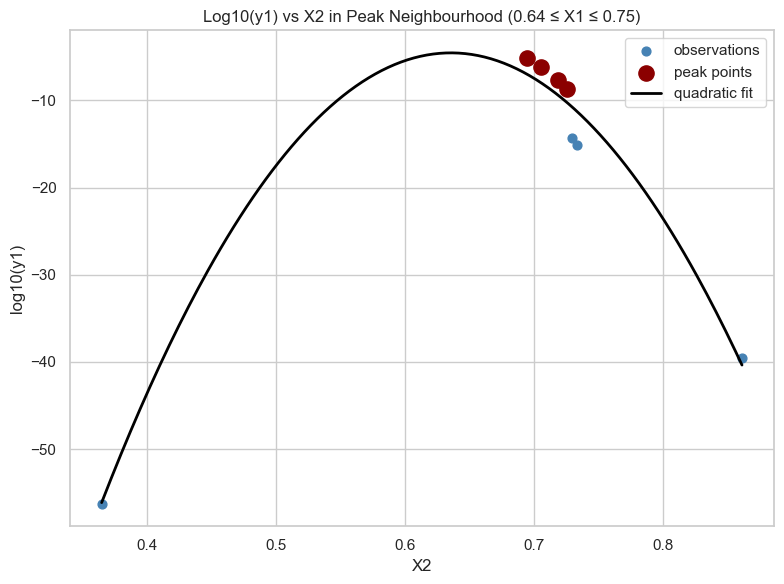

In [31]:
# restrict to peak neighbourhood
df_peak = df_f1[(df_f1["X1"] >= 0.64) & (df_f1["X1"] <= 0.75) & (df_f1["y1"] > 0)]

# compute log10(y)
df_peak["log10_y"] = np.log10(df_peak["y1"])

# identify the 3–4 peak observations (highest y)
df_peak_sorted = df_peak.sort_values("y1", ascending=False)
df_peaks = df_peak_sorted.head(4)

# quadratic fit: log10(y) = a + b*X2 + c*X2^2
X2_vals = df_peak["X2"].values
logy_vals = df_peak["log10_y"].values
coeffs = np.polyfit(X2_vals, logy_vals, deg=2)
poly = np.poly1d(coeffs)

# generate smooth curve
x2_grid = np.linspace(X2_vals.min(), X2_vals.max(), 200)
y_fit = poly(x2_grid)

# plot
plt.figure(figsize=(8, 6))

# all points
plt.scatter(df_peak["X2"], df_peak["log10_y"], s=40, color="steelblue", label="observations")

# highlight peak points
plt.scatter(df_peaks["X2"], df_peaks["log10_y"], s=120, color="darkred", label="peak points")

# quadratic curve
plt.plot(x2_grid, y_fit, color="black", linewidth=2, label="quadratic fit")

plt.xlabel("X2")
plt.ylabel("log10(y1)")
plt.title("Log10(y1) vs X2 in Peak Neighbourhood (0.64 ≤ X1 ≤ 0.75)")
plt.legend()
plt.tight_layout()
plt.show()


## Topological Data Analysis

In [32]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [33]:
def build_mapper_graph(X, filter_vals, n_intervals=5, overlap_frac=0.1,
                       cluster_eps=0.1, cluster_min_samples=1):
    """
    simple mapper implementation:
      - 1D filter function
      - interval cover with overlap
      - DBSCAN clustering inside each interval
      - nodes represent clusters
      - edges connect nodes sharing data points
    """

    X = np.asarray(X)
    filter_vals = np.asarray(filter_vals)

    # compute interval boundaries
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_length = (fmax - fmin) / n_intervals
    overlap = interval_length * overlap_frac

    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_length - overlap
        end = fmin + (i + 1) * interval_length + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0

    # store cluster membership for edge construction
    interval_clusters = []

    for (start, end) in intervals:
        # points inside interval
        mask = (filter_vals >= start) & (filter_vals <= end)
        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            interval_clusters.append([])
            continue

        X_sub = X[idxs]

        # cluster inside interval
        labels = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit_predict(X_sub)
        unique_labels = set(labels)

        clusters = []
        for lab in unique_labels:
            if lab == -1:
                continue  # ignore noise
            cluster_indices = idxs[labels == lab]

            # add node
            G.add_node(node_id, indices=cluster_indices, size=len(cluster_indices))
            clusters.append(node_id)
            node_id += 1

        interval_clusters.append(clusters)

    # build edges: clusters sharing points
    for i in range(len(interval_clusters) - 1):
        for a in interval_clusters[i]:
            for b in interval_clusters[i + 1]:
                # check overlap in data indices
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G

Mapper for f1 (transformed y1)
  mapper diagnostics: nodes=7, edges=5, connected_components=2
  node size: mean=3.86, min=2, max=7
  top nodes by max y (node, size, mean_y, max_y):
    node 6: size=3, mean_y=1.3986, max_y=1.7117
    node 5: size=6, mean_y=0.7313, max_y=1.1243
    node 4: size=7, mean_y=0.2834, max_y=0.6407
    node 3: size=4, mean_y=-0.2033, max_y=0.1642
    node 2: size=2, mean_y=-0.1652, max_y=-0.0545


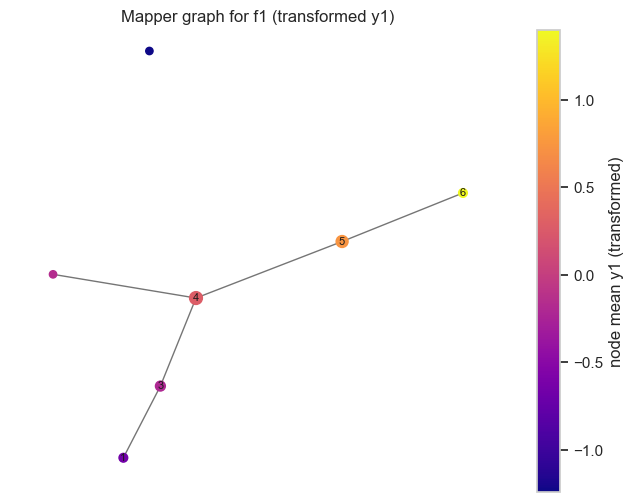

In [34]:
print("Mapper for f1 (transformed y1)")

# filter values = transformed y1
filter_vals = y_f1.copy()

# build mapper graph
G_f1 = build_mapper_graph(
    X_f1,
    filter_vals,
    n_intervals=6,
    overlap_frac=0.35,
    cluster_eps=0.40,
    cluster_min_samples=2
)

# diagnostics
n_nodes = G_f1.number_of_nodes()
n_edges = G_f1.number_of_edges()
n_components = nx.number_connected_components(G_f1)

print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")

if n_nodes > 0:
    node_sizes = np.array([G_f1.nodes[n]["size"] for n in G_f1.nodes])
    print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")

    # compute node-level y statistics
    node_max_y = []
    node_mean_y = []

    for nkey in G_f1.nodes:
        idxs = G_f1.nodes[nkey]["indices"]
        node_max_y.append(float(filter_vals[idxs].max()))
        node_mean_y.append(float(filter_vals[idxs].mean()))

    node_max_y = np.array(node_max_y)
    node_mean_y = np.array(node_mean_y)

    # top 5 nodes by max y
    top_idx = np.argsort(node_max_y)[::-1][:5]
    print("  top nodes by max y (node, size, mean_y, max_y):")
    for t in top_idx:
        nkey = list(G_f1.nodes)[t]
        print(
            f"    node {nkey}: size={G_f1.nodes[nkey]['size']}, "
            f"mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}"
        )

# plot mapper graph
if n_nodes > 0:
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G_f1, seed=0)

    node_colors = [np.mean(filter_vals[G_f1.nodes[n]["indices"]]) for n in G_f1.nodes]
    node_sizes_plot = [
        5 + 80 * (G_f1.nodes[n]["size"] / node_sizes.max())
        for n in G_f1.nodes
    ]

    nodes = nx.draw_networkx_nodes(
        G_f1, pos,
        node_color=node_colors,
        cmap="plasma",
        node_size=node_sizes_plot
    )
    nx.draw_networkx_edges(G_f1, pos, alpha=0.6)

    # label only larger nodes
    labels = {
        n: f"{n}"
        for n in G_f1.nodes
        if G_f1.nodes[n]["size"] >= max(2, int(node_sizes.mean()))
    }
    nx.draw_networkx_labels(G_f1, pos, labels=labels, font_size=8)

    plt.colorbar(nodes, label="node mean y1 (transformed)")
    plt.title("Mapper graph for f1 (transformed y1)")
    plt.axis("off")
    plt.show()

# store results
results_f1_mapper = {
    "graph": G_f1,
    "filter_vals": filter_vals,
    "input_cols": input_cols_f1,
    "output_col": output_col_f1
}


## K-means Clustering

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

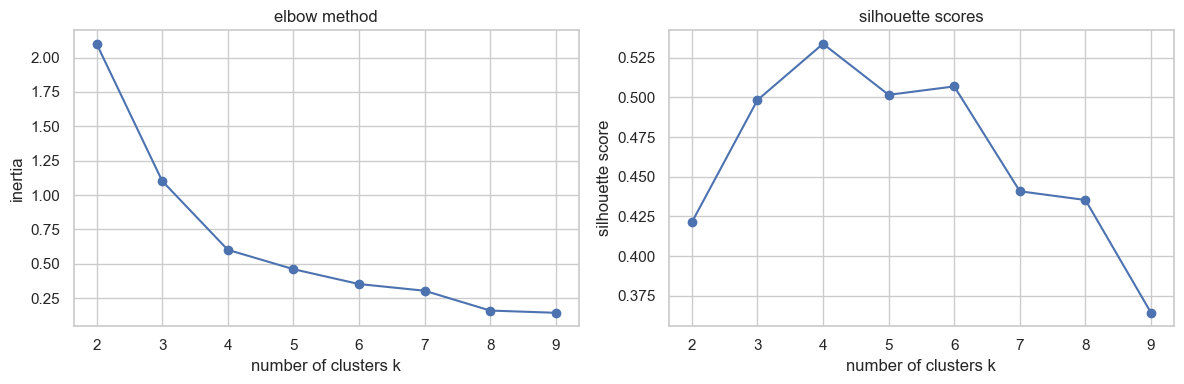

best number of clusters based on silhouette score: 4
cluster labels added to f1 dataframe


,X1,X2,y1,cluster
0,0.319404,0.762959,1.322677e-79,3
1,0.574329,0.879898,1.033078e-46,1
2,0.731024,0.733000,7.710875e-16,1
3,0.840353,0.264732,3.341771e-124,2
4,0.650114,0.681526,-3.606063e-03,1


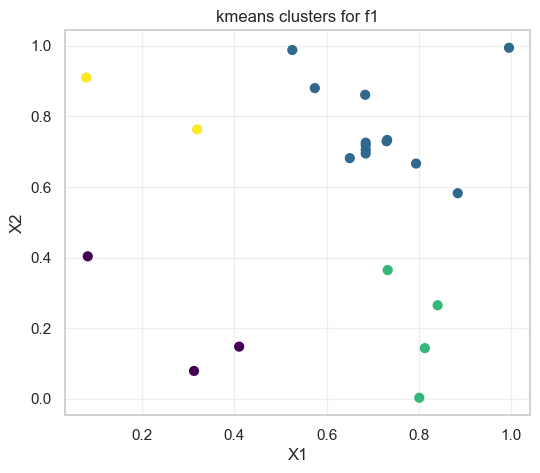

In [36]:
# prepare data
df_f1_kmeans = df_f1.copy()
input_cols_f1 = [c for c in df_f1_kmeans.columns if c.startswith("X")]
X_f1 = df_f1_kmeans[input_cols_f1].values

# test k from 2 to 9
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_f1)

    inertias.append(km.inertia_)

    labels = km.labels_
    score = silhouette_score(X_f1, labels)
    sil_scores.append(score)

# plot elbow + silhouette
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("number of clusters k")
plt.ylabel("inertia")
plt.title("elbow method")

plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("number of clusters k")
plt.ylabel("silhouette score")
plt.title("silhouette scores")

plt.tight_layout()
plt.show()

# choose best k
best_k = k_values[np.argmax(sil_scores)]
print("best number of clusters based on silhouette score:", best_k)

# fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
kmeans_final.fit(X_f1)

cluster_labels = kmeans_final.labels_

# add labels to dataframe
df_f1_kmeans["cluster"] = cluster_labels

print("cluster labels added to f1 dataframe")
display(df_f1_kmeans.head())

# optional scatter plot (only if 2D)
if X_f1.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_f1[:, 0], X_f1[:, 1],
        c=cluster_labels,
        cmap="viridis",
        s=40
    )
    plt.xlabel(input_cols_f1[0])
    plt.ylabel(input_cols_f1[1])
    plt.title("kmeans clusters for f1")
    plt.grid(alpha=0.3)
    plt.show()

## Hierarchical Clustering

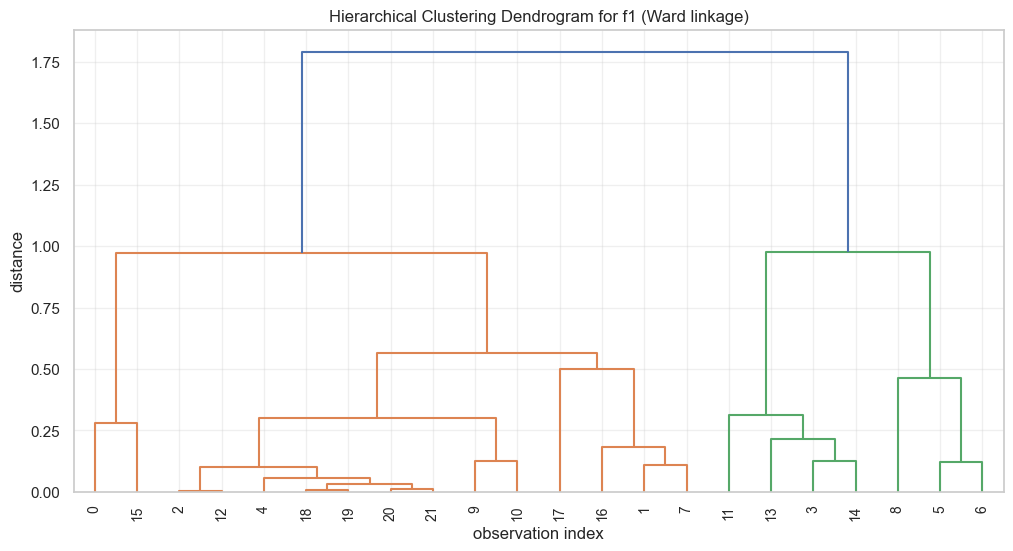

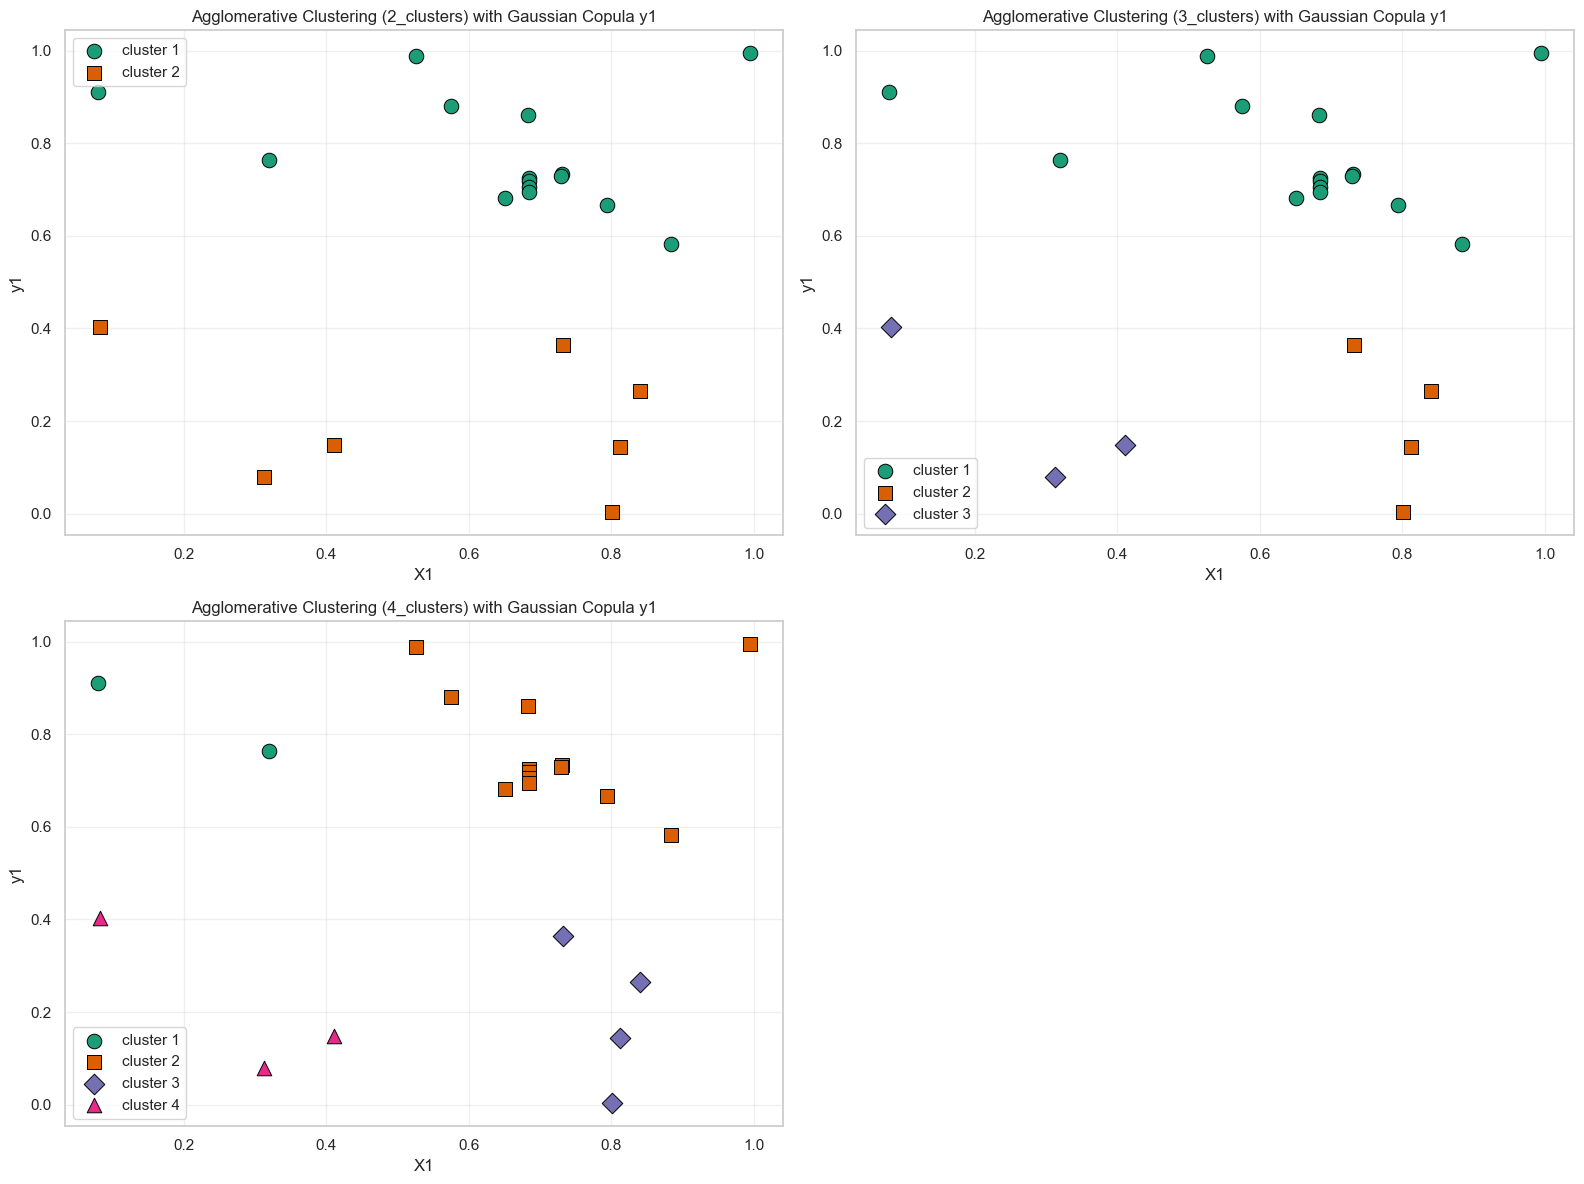


Centroid Diagnostics for 2_clusters
cluster 1: centroid = [0.64690485 0.77543101]
cluster 2: centroid = [0.57020028 0.20073074]

centroid distance matrix:
          1         2
1  0.000000  0.579797
2  0.579797  0.000000

Centroid Diagnostics for 3_clusters
cluster 1: centroid = [0.64690485 0.77543101]
cluster 2: centroid = [0.7964416  0.19383765]
cluster 3: centroid = [0.26854518 0.20992153]

centroid distance matrix:
          1         2         3
1  0.000000  0.600510  0.680409
2  0.600510  0.000000  0.528141
3  0.680409  0.528141  0.000000

Centroid Diagnostics for 4_clusters
cluster 1: centroid = [0.19933444 0.83640369]
cluster 2: centroid = [0.71576184 0.7660506 ]
cluster 3: centroid = [0.7964416  0.19383765]
cluster 4: centroid = [0.26854518 0.20992153]

centroid distance matrix:
          1         2         3         4
1  0.000000  0.521197  0.877170  0.630294
2  0.521197  0.000000  0.577873  0.713640
3  0.877170  0.577873  0.000000  0.528141
4  0.630294  0.713640  0.528141 

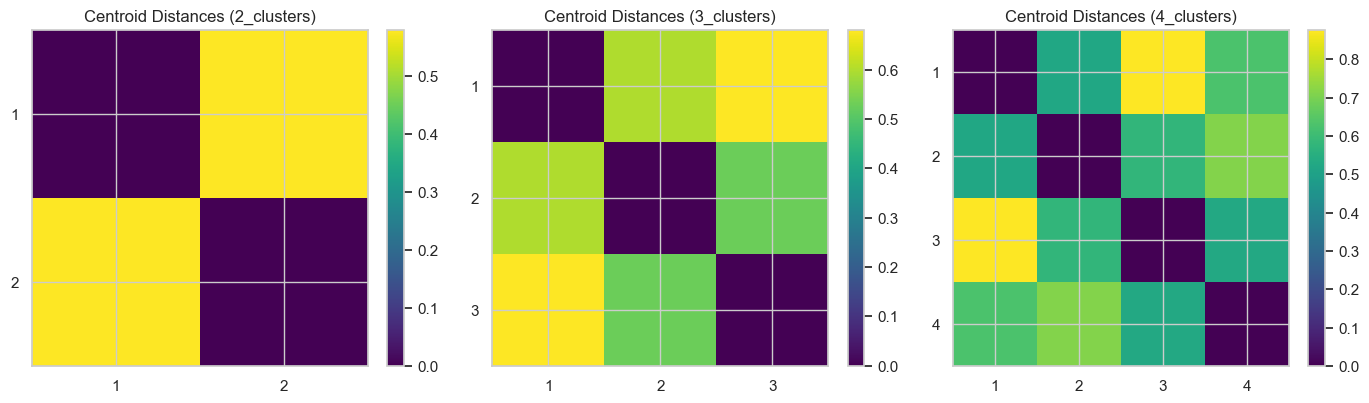

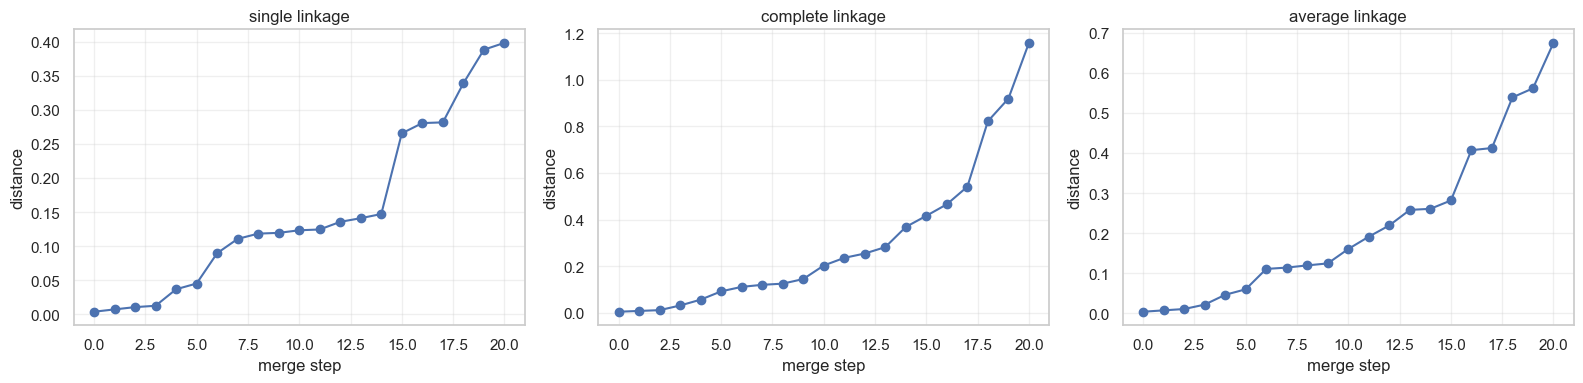

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# copy dataset
df_f1_hc = df_f1.copy()

# apply your existing gaussian_copula_transform()
y_raw = df_f1_hc["y1"].values.astype(float)
y_copula = gaussian_copula_transform(y_raw)
df_f1_hc["y1"] = y_copula

# define inputs and output
input_cols_f1 = [c for c in df_f1_hc.columns if c.startswith("X")]
output_col_f1 = "y1"

X_f1 = df_f1_hc[input_cols_f1].values.astype(float)
y_f1 = df_f1_hc[output_col_f1].values.astype(float)

# compute linkage matrices for all metrics
Z_single = linkage(X_f1, method="single")
Z_complete = linkage(X_f1, method="complete")
Z_average = linkage(X_f1, method="average")
Z_ward = linkage(X_f1, method="ward")  # main dendrogram

# dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z_ward, labels=df_f1_hc.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram for f1 (Ward linkage)")
plt.xlabel("observation index")
plt.ylabel("distance")
plt.grid(alpha=0.3)
plt.show()

# cluster cut-offs
cluster_solutions = {
    "2_clusters": fcluster(Z_ward, 2, criterion="maxclust"),
    "3_clusters": fcluster(Z_ward, 3, criterion="maxclust"),
    "4_clusters": fcluster(Z_ward, 4, criterion="maxclust")
}

# attach cluster labels
for name, labels in cluster_solutions.items():
    df_f1_hc[name] = labels

# colour-blind-safe palette
palette = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666"
]

# marker symbols
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

# scatter plots for each cluster solution
plt.figure(figsize=(16, 12))
solutions = ["2_clusters", "3_clusters", "4_clusters"]

for i, sol in enumerate(solutions, 1):
    ax = plt.subplot(2, 2, i)
    labels = df_f1_hc[sol].values

    for lab in np.unique(labels):
        idx = np.where(labels == lab)[0]
        ax.scatter(
            X_f1[idx, 0],
            X_f1[idx, 1],
            c=palette[(lab - 1) % len(palette)],
            marker=markers[(lab - 1) % len(markers)],
            s=110,
            edgecolor="black",
            linewidth=0.7,
            label=f"cluster {lab}"
        )

    ax.set_xlabel(input_cols_f1[0])
    ax.set_ylabel(output_col_f1)
    ax.set_title(f"Agglomerative Clustering ({sol}) with Gaussian Copula y1")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# compute centroids and centroid distances
centroid_results = {}

for sol in solutions:
    labels = df_f1_hc[sol].values
    unique_labels = np.unique(labels)

    centroids = []
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        centroids.append(X_f1[idx].mean(axis=0))
    centroids = np.array(centroids)

    centroid_dist = squareform(pdist(centroids))

    centroid_results[sol] = {
        "labels": unique_labels,
        "centroids": centroids,
        "distances": centroid_dist
    }

    print(f"\nCentroid Diagnostics for {sol}")
    for lab, c in zip(unique_labels, centroids):
        print(f"cluster {lab}: centroid = {c}")
    print("\ncentroid distance matrix:")
    print(pd.DataFrame(centroid_dist, index=unique_labels, columns=unique_labels))

# visualise centroid distances
plt.figure(figsize=(14, 4))

for i, sol in enumerate(solutions, 1):
    ax = plt.subplot(1, 3, i)
    dist = centroid_results[sol]["distances"]
    labels = centroid_results[sol]["labels"]

    im = ax.imshow(dist, cmap="viridis")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_title(f"Centroid Distances ({sol})")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# visualise linkage distances for single, complete, average
plt.figure(figsize=(16, 4))

linkage_methods = {
    "single linkage": Z_single,
    "complete linkage": Z_complete,
    "average linkage": Z_average
}

for i, (name, Zm) in enumerate(linkage_methods.items(), 1):
    ax = plt.subplot(1, 3, i)
    ax.plot(Zm[:, 2], marker="o", linestyle="-")
    ax.set_title(name)
    ax.set_xlabel("merge step")
    ax.set_ylabel("distance")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Pairwise Distance Distribution Among Top Observations

In [38]:
# select top 5 observations by y1
df_top = df_f1.sort_values("y1", ascending=False).head(5)

# extract X1 and X2 as a matrix
coords = df_top[["X1", "X2"]].values

# compute pairwise euclidean distances
dists = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))

# take upper triangle without diagonal
pairwise = dists[np.triu_indices(5, k=1)]

print("Pairwise distances among top 5 observations (X1, X2):")
print("mean distance:", pairwise.mean())
print("min distance:", pairwise.min())


Pairwise distances among top 5 observations (X1, X2):
mean distance: 0.030463559169401532
min distance: 0.007353000000000054


## Quadratic Residual Diagnostic (log10 space)

In [39]:
# extract X2 and log10(y) from the peak neighbourhood
df_peak = df_f1[(df_f1["X1"] >= 0.64) & (df_f1["X1"] <= 0.75) & (df_f1["y1"] > 0)].copy()
df_peak["log10_y"] = np.log10(df_peak["y1"])

X2_vals = df_peak["X2"].values
logy_vals = df_peak["log10_y"].values

# fit quadratic: log10(y) = a + b*X2 + c*X2^2
coeffs = np.polyfit(X2_vals, logy_vals, deg=2)
poly = np.poly1d(coeffs)

# predictions and residuals
y_pred = poly(X2_vals)
residuals = logy_vals - y_pred

# compute R-squared in log10 space
ss_res = np.sum((logy_vals - y_pred)**2)
ss_tot = np.sum((logy_vals - np.mean(logy_vals))**2)
r2 = 1 - ss_res/ss_tot

print("=== Quadratic Residual Diagnostic (log10 space) ===")
print(f"R-squared: {r2:.4f}")
print(f"max residual: {np.max(np.abs(residuals)):.4f} log units")
print(f"mean residual: {np.mean(np.abs(residuals)):.4f} log units")

if r2 >= 0.95:
    print("quadratic fit is strong (R² ≥ 0.95) — peak estimate is trustworthy")
elif r2 >= 0.90:
    print("quadratic fit is borderline (0.90 ≤ R² < 0.95) — use with caution")
else:
    print("quadratic fit is weak (R² < 0.90) — fallback step recommended")


=== Quadratic Residual Diagnostic (log10 space) ===
R-squared: 0.9838
max residual: 3.8719 log units
mean residual: 1.8828 log units
quadratic fit is strong (R² ≥ 0.95) — peak estimate is trustworthy


# Distrbution Analysis

f1 raw – feature and output distributions


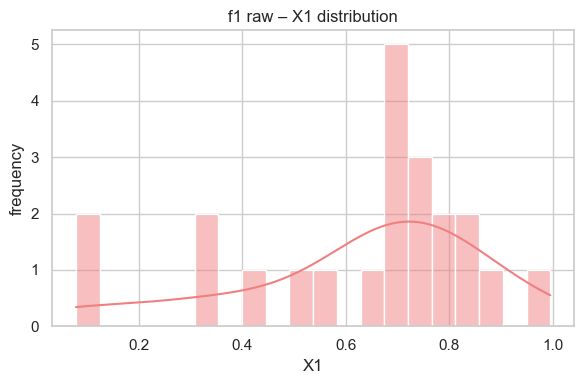

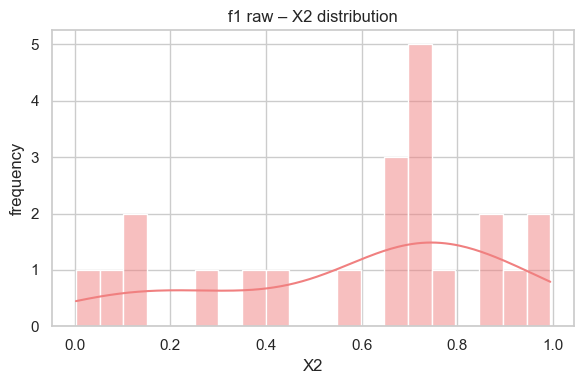

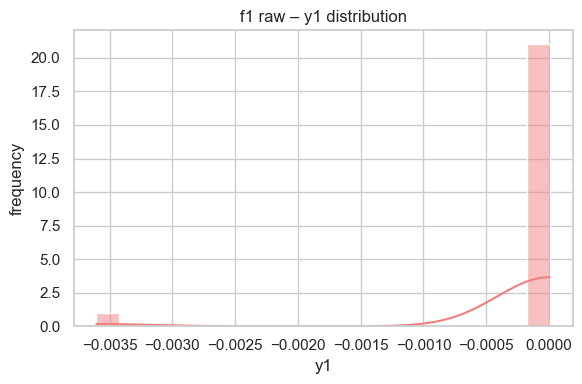

In [40]:
print("f1 raw – feature and output distributions")

all_cols_raw_f1 = input_cols + [output_cols[0]]   # EXACTLY your variables

for col in all_cols_raw_f1:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f1[col],
        kde=True,
        bins=20,
        color="lightcoral"
    )

    plt.title(f"f1 raw – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()


f1 – raw inputs + log10(y1) distribution plots


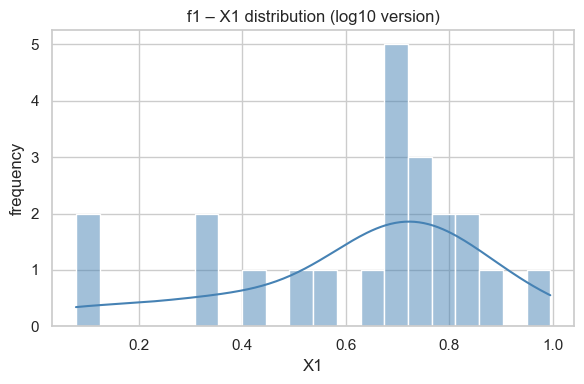

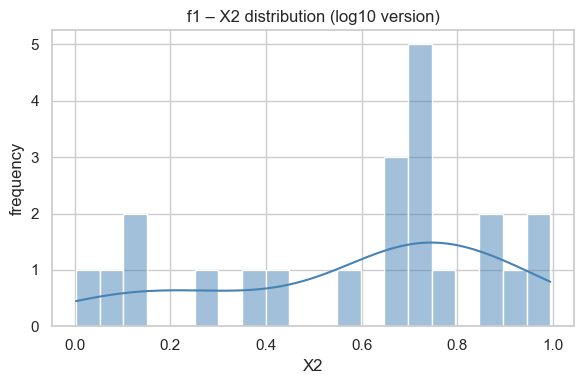

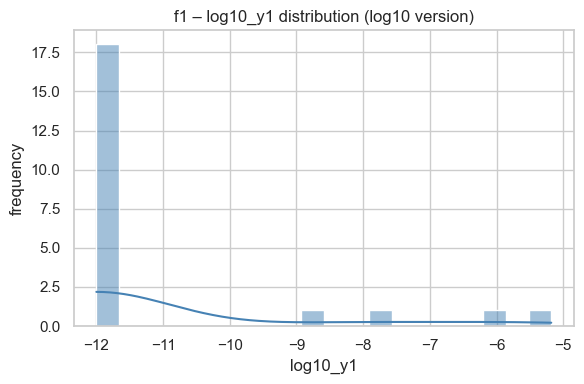

In [41]:
print("f1 – raw inputs + log10(y1) distribution plots")

df_log = df_f1.copy()
df_log["log10_y1"] = np.log10(df_log[output_cols[0]].clip(lower=1e-12))

cols_to_plot = input_cols + ["log10_y1"]

for col in cols_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_log[col], kde=True, bins=20, color="steelblue")
    plt.title(f"f1 – {col} distribution (log10 version)")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.tight_layout()
    plt.show()




### Line Plot of y Values

log10(y1) – y vs instance index


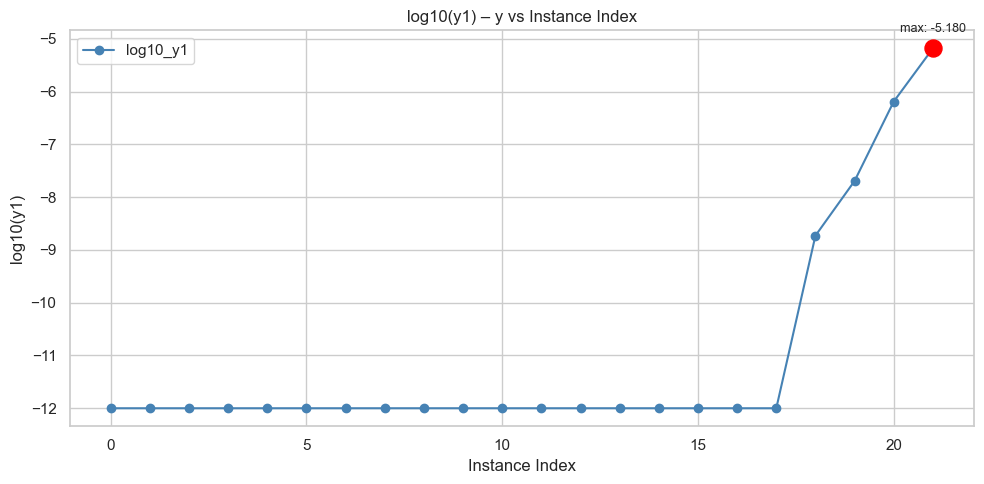

In [42]:
df_f1_log = df_f1.copy()

# log10 transform (safe for zeros)
df_f1_log["log10_y1"] = np.log10(df_f1_log[output_cols[0]].clip(lower=1e-12))

print("log10(y1) – y vs instance index")

y_log = df_f1_log["log10_y1"].values
x = np.arange(len(y_log))

plt.figure(figsize=(10, 5))

# line + points
plt.plot(x, y_log, marker="o", linestyle="-", color="steelblue", label="log10_y1")

# highlight maximum
max_idx = np.argmax(y_log)
max_val = y_log[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("log10(y1) – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("log10(y1)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()





Gaussian Copula – y1 vs instance index


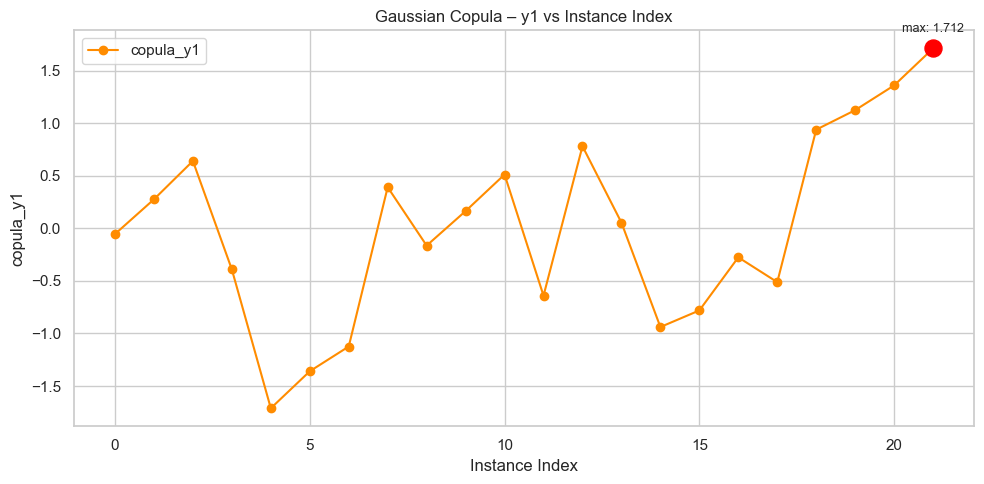

In [43]:
# 1. Create a clean copy of the RAW data
df_f1_copula_plot = df_f1.copy()

# 2. Apply Gaussian copula transform to y1 on the COPY
df_f1_copula_plot["copula_y1"] = gaussian_copula_transform(
    df_f1_copula_plot[output_cols[0]].values
)

print("Gaussian Copula – y1 vs instance index")

# 3. Extract transformed y
y_cop = df_f1_copula_plot["copula_y1"].values
x = np.arange(len(y_cop))

# 4. Plot
plt.figure(figsize=(10, 5))

plt.plot(x, y_cop, marker="o", linestyle="-", color="darkorange", label="copula_y1")

# highlight maximum
max_idx = np.argmax(y_cop)
max_val = y_cop[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("Gaussian Copula – y1 vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("copula_y1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### f1 | Three-Point Quadratic Ridge Peak Targeting with Empirical Gradient Validation

In [44]:
# Separate inputs (X) and outputs (y)
X_train_1 = df_f1[[c for c in df_f1.columns if c.startswith("X")]].values
y_train_1 = df_f1["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]
 [0.732162   0.364472  ]
 [0.81265    0.143347  ]
 [0.079265   0.909848  ]
 [0.525569   0.987823  ]
 [0.994902   0.994221  ]
 [0.684583   0.725353  ]
 [0.684583   0.718     ]
 [0.684583   0.705339  ]
 [0.684583   0.694641  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015  5.47377612e-057 -1.06293312e-161  2.60788262e-248
  2.23603281e-098  3.02997127e-187  1.86704411e-009  2.03320460e-008
  6.49621320e-007  6.60488810e-006]


In [45]:
# the four observations currently in the fit:
#   row 18: x2=0.7254, log10(y)=-8.73  (far from peak, pulling rightward)
#   row 19: x2=0.7180, log10(y)=-7.69
#   row 20: x2=0.7053, log10(y)=-6.19
#   row 21: x2=0.6946, log10(y)=-5.18  (current best)

# fit with rows 19, 20, 21 only (exclude row 18)
x2_three = np.array([0.7180, 0.7053, 0.6946])
log_y_three = np.array([-7.6918, -6.1873, -5.1801])

coeffs = np.polyfit(x2_three, log_y_three, deg=2)
a, b, c = coeffs

print(f"three-point fit (rows 19, 20, 21 only):")
print(f"  a={a:.4f}, b={b:.4f}, c={c:.4f}")
print(f"  a < 0: {a < 0}")

if a < 0:
    x2_peak = -b / (2.0 * a)
    log_y_peak = np.polyval(coeffs, x2_peak)
    print(f"  estimated peak x2: {x2_peak:.6f}")
    print(f"  estimated peak y:  {10**log_y_peak:.4e}")
    print(f"  improvement over current best (6.605e-06): "
          f"{10**log_y_peak / 6.604888e-06:.1f}x")
else:
    print(f"  quadratic opens upward: gradient still monotonic")

# also show what happens with rows 20 and 21 only (two-point plus slope)
print(f"\ntwo most recent steps for context:")
print(f"  row 19 to 20: delta={-6.1873 - (-7.6918):+.4f} over step {abs(0.7053-0.7180):.4f}")
print(f"  row 20 to 21: delta={-5.1801 - (-6.1873):+.4f} over step {abs(0.6946-0.7053):.4f}")
print(f"  deceleration: second delta is smaller, confirming approach to peak")

three-point fit (rows 19, 20, 21 only):
  a=-1039.9028, b=1361.6291, c=-449.2466
  a < 0: True
  estimated peak x2: 0.654691
  estimated peak y:  2.9938e-04
  improvement over current best (6.605e-06): 45.3x

two most recent steps for context:
  row 19 to 20: delta=+1.5045 over step 0.0127
  row 20 to 21: delta=+1.0072 over step 0.0107
  deceleration: second delta is smaller, confirming approach to peak


In [46]:
def propose_f1_query(X_train_1, y_train_1,
                                    x1_fixed=0.684583,
                                    min_x2_sep=0.005):
    """
    final week 13 strategy using only the three most recent productive
    observations: rows 19, 20, 21.

    row 18 (x2=0.7254, y=1.87e-09) is excluded because it is
    far from the current productive cluster and pulls the quadratic
    peak rightward. the three most recent observations bracket
    the local curvature of the ridge more accurately.

    with three points and a degree-2 polynomial the fit is exact
    (zero residuals). the peak is a direct interpolation of the
    curvature from the three most informative observations.
    """
    print("f1 week 13: three-point quadratic (rows 19, 20, 21 only)")
    print(f"x1 fixed: {x1_fixed}")
    print(f"row 18 excluded: x2=0.7254 is too far from current cluster")

    best_idx = np.argmax(y_train_1)
    best_x = X_train_1[best_idx]
    best_y = y_train_1[best_idx]
    print(f"\ncurrent best: y={best_y:.4e} "
          f"at x1={best_x[0]:.6f}, x2={best_x[1]:.6f}")

    # step 1: select only the three most recent productive observations
    # threshold raised to y >= 1e-08 to exclude row 18 (y=1.867e-09)
    # this keeps rows 19, 20, 21 which are all within 0.030 of each other
    # in x2 and form a tight local cluster around the peak region
    recent_mask = (
        (np.abs(X_train_1[:, 0] - x1_fixed) < 0.05) &
        (X_train_1[:, 1] >= 0.680) &
        (X_train_1[:, 1] <= 0.730) &
        (y_train_1 >= 1e-08)
    )
    recent_indices = np.where(recent_mask)[0]
    x2_recent = X_train_1[recent_mask, 1]
    y_recent = y_train_1[recent_mask]

    sort_order = np.argsort(x2_recent)[::-1]
    x2_sorted = x2_recent[sort_order]
    y_sorted = y_recent[sort_order]
    idx_sorted = recent_indices[sort_order]

    print(f"\nthree most recent observations (y >= 1e-08):")
    for i in range(len(idx_sorted)):
        print(f"  row {idx_sorted[i]}: x2={x2_sorted[i]:.4f}, "
              f"y={y_sorted[i]:.4e}, "
              f"log10(y)={np.log10(y_sorted[i]):.4f}")

    # step 2: fit quadratic to the three most recent points
    # with exactly three points and degree 2 the fit is exact
    # the peak location is a pure interpolation of local curvature
    log_y_recent = np.log10(y_recent)
    coeffs = np.polyfit(x2_recent, log_y_recent, deg=2)
    a, b, c = coeffs

    print(f"\nthree-point quadratic fit (exact interpolation):")
    print(f"  a={a:.4f}, b={b:.4f}, c={c:.4f}")
    print(f"  a < 0: {a < 0} (required for finite maximum)")

    if a < 0:
        x2_peak = -b / (2.0 * a)
        log_y_peak = np.polyval(coeffs, x2_peak)
        print(f"  estimated peak x2: {x2_peak:.6f}")
        print(f"  estimated peak log10(y): {log_y_peak:.4f}")
        print(f"  estimated peak y: {10**log_y_peak:.4e}")
        print(f"  improvement over current best: "
              f"{10**log_y_peak / best_y:.1f}x")

        # validate: peak must be below the current best x2
        # since all improvements have come from moving downward in x2
        if x2_peak >= best_x[1]:
            print(f"\n  warning: peak estimate {x2_peak:.4f} is above "
                  f"current best {best_x[1]:.4f}")
            print(f"  this is inconsistent with the empirical gradient")
            print(f"  falling back to average step size")
            x2_peak = None
    else:
        x2_peak = None
        print(f"  quadratic opens upward: peak not yet reached")

    # step 3: determine submission x2
    if x2_peak is not None and x2_peak < best_x[1]:
        x2_proposed = x2_peak
        method = "three-point quadratic peak (rows 19, 20, 21)"
        print(f"\npeak below current best: using three-point estimate")
        print(f"x2 proposed: {x2_proposed:.6f}")
    else:
        # fallback: use average of last two steps
        step_20_21 = abs(0.7053 - 0.6946)
        step_19_20 = abs(0.7180 - 0.7053)
        avg_step = (step_20_21 + step_19_20) / 2
        x2_proposed = best_x[1] - avg_step
        x2_proposed = np.clip(x2_proposed, 0.0, 1.0)
        method = "average gradient step fallback"
        print(f"\nfallback: average step {avg_step:.4f} below current best")
        print(f"x2 proposed: {x2_proposed:.6f}")

    # step 4: symmetric separation check
    near_x1 = np.abs(X_train_1[:, 0] - x1_fixed) < 0.05
    x2_existing = X_train_1[near_x1, 1]

    x2_candidates = np.linspace(
        max(0.0, x2_proposed - 0.030),
        min(1.0, x2_proposed + 0.010),
        3000
    )
    min_seps = np.array([
        np.abs(x2_existing - x2c).min()
        for x2c in x2_candidates
    ])
    safe_mask = min_seps >= min_x2_sep
    safe_candidates = x2_candidates[safe_mask]

    if len(safe_candidates) > 0:
        distances = np.abs(safe_candidates - x2_proposed)
        best_safe_idx = np.argmin(distances)
        x2_final = safe_candidates[best_safe_idx]
        sep = min_seps[safe_mask][best_safe_idx]
    else:
        x2_final = x2_proposed
        sep = np.abs(x2_existing - x2_final).min()
        print(f"warning: no safe point found, using proposed directly")

    next_x = np.array([x1_fixed, x2_final])

    print(f"\nfinal submission point")
    print(f"method: {method}")
    print(f"x1={next_x[0]:.6f}")
    print(f"x2={next_x[1]:.6f}")
    print(f"separation from nearest same-x1 observation: {sep:.6f}")

    print(f"\ngradient history")
    rows = [
        (0.7180, 2.033e-08,  "row 19"),
        (0.7053, 6.496e-07,  "row 20"),
        (0.6946, 6.605e-06,  "row 21 (current best)"),
    ]
    prev_ly = None
    prev_x2 = None
    for x2v, yv, label in rows:
        ly = np.log10(yv)
        if prev_ly is not None:
            delta = ly - prev_ly
            step = abs(x2v - prev_x2)
            rate = delta / step
            print(f"  {label}: x2={x2v:.4f}, log10(y)={ly:.4f}, "
                  f"delta={delta:+.4f}, rate={rate:.1f}/unit")
        else:
            print(f"  {label}: x2={x2v:.4f}, "
                  f"log10(y)={ly:.4f}  (baseline)")
        prev_ly = ly
        prev_x2 = x2v

    if x2_peak is not None:
        print(f"\n  three-point peak estimate: x2={x2_peak:.6f}")
    print(f"  proposed: x2={next_x[1]:.6f}")
    print(f"  this is the final query for f1")

    return next_x

next_point = propose_f1_query(X_train_1, y_train_1)
print(f"\nsubmit for f1 week 13 (final): "
    f"x1={next_point[0]:.6f}, x2={next_point[1]:.6f}")

f1 week 13: three-point quadratic (rows 19, 20, 21 only)
x1 fixed: 0.684583
row 18 excluded: x2=0.7254 is too far from current cluster

current best: y=6.6049e-06 at x1=0.684583, x2=0.694641

three most recent observations (y >= 1e-08):
  row 19: x2=0.7180, y=2.0332e-08, log10(y)=-7.6918
  row 20: x2=0.7053, y=6.4962e-07, log10(y)=-6.1873
  row 21: x2=0.6946, y=6.6049e-06, log10(y)=-5.1801

three-point quadratic fit (exact interpolation):
  a=-1056.5053, b=1384.9374, c=-457.4230
  a < 0: True (required for finite maximum)
  estimated peak x2: 0.655433
  estimated peak log10(y): -3.5560
  estimated peak y: 2.7796e-04
  improvement over current best: 42.1x

peak below current best: using three-point estimate
x2 proposed: 0.655433

final submission point
method: three-point quadratic peak (rows 19, 20, 21)
x1=0.684583
x2=0.655430
separation from nearest same-x1 observation: 0.026096

gradient history
  row 19: x2=0.7180, log10(y)=-7.6919  (baseline)
  row 20: x2=0.7053, log10(y)=-6.1874, 

In [47]:
from sklearn.preprocessing import StandardScaler
# standardise copula transformed outputs to zero mean and unit variance
def standardise(y_copula):
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y_copula.reshape(-1, 1)).ravel()
    return y_scaled, scaler


copula-normalised y table
    y_copula  y_normalized
0  -0.054519     -0.062145
1   0.275921      0.314518
2   0.640667      0.730285
3  -0.391196     -0.445918
4  -1.711675     -1.951110
5  -1.359737     -1.549942
6  -1.124338     -1.281614
7   0.391196      0.445918
8  -0.164211     -0.187181
9   0.164211      0.187181
10  0.511936      0.583547
11 -0.640667     -0.730285
12  0.781034      0.890287
13  0.054519      0.062145
14 -0.938814     -1.070139
15 -0.781034     -0.890287
16 -0.275921     -0.314518
17 -0.511936     -0.583547
18  0.938814      1.070139
19  1.124338      1.281614
20  1.359737      1.549942
21  1.711675      1.951110


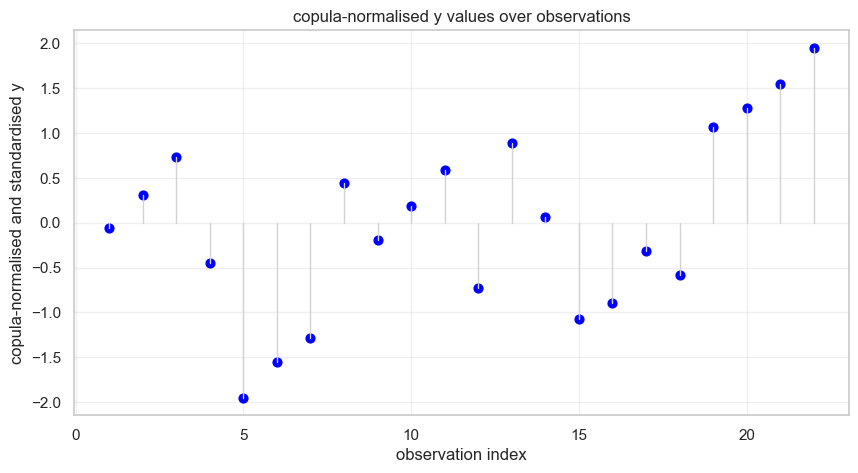

In [48]:

# apply copula transform
y_copula = gaussian_copula_transform(y_train_1)

# apply standardisation (extract only the scaled values)
y_normalized, _ = standardise(y_copula)

# x-axis values
x_vals = np.arange(1, len(y_normalized) + 1)

# build a table for inspection
results_table = pd.DataFrame({
    "y_copula": y_copula,
    "y_normalized": y_normalized
})

print("\ncopula-normalised y table")
print(results_table)

# create the plot
plt.figure(figsize=(10, 5))

# draw vertical lines from x-axis to each point
for x, y in zip(x_vals, y_normalized):
    plt.plot([x, x], [0, y], color="lightgray", linewidth=1)

# draw the points
plt.scatter(x_vals, y_normalized, color="blue", s=40)

# labels and title
plt.xlabel("observation index")
plt.ylabel("copula-normalised and standardised y")
plt.title("copula-normalised y values over observations")

# grid for readability
plt.grid(alpha=0.3)



In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")